In [1]:
!uv add "langgraph==1.2.9" "langchain-groq==1.1.3" "python-dotenv>=1.0.1" "ipykernel>=7.0.0"

Resolved 71 packages in 0.77ms
Checked 66 packages in 1ms


In [2]:
from typing import List, Optional, TypedDict

In [3]:
class AgentState(TypedDict, total=False):
    user_input: str
    task_list: List[str]
    final_output: Optional[str]

In [4]:
import os

groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise RuntimeError("GROQ_API_KEY is not available. Rebuild the Codespace after adding the secret.")

In [5]:
from langchain_groq import ChatGroq
llm = ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x747ca7ac86b0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x747ca7969b80>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
def planner_node(state: dict) -> dict:
    prompt = f"Break this task into 2-3 steps: {state['user_input']}"
    response  = llm.invoke(prompt)  # Assuming you have a function defined to call the LLM
    steps = response.content
    step_lines = [line.strip("- ").strip() for line in steps.split("\n") if line.strip()]
    print("📌 Planner Output:", step_lines)
    return {"task_list": step_lines}

In [7]:
def executor_node(state: dict) -> dict:
    steps = state.get("task_list", [])
    final_output = " -> ".join(steps) + " -> Done!"
    return {"final_output": final_output}

In [8]:
import langgraph.graph

In [9]:
from langgraph.graph import StateGraph

In [10]:
graph = StateGraph(state_schema=AgentState)

In [11]:
graph.add_node("planner", planner_node)
graph.add_node("executor", executor_node)

graph.set_entry_point("planner")
graph.add_edge("planner", "executor")
graph.set_finish_point("executor")

In [12]:
graph_compiled = graph.compile()

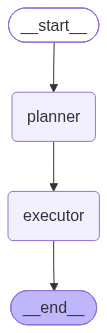

In [13]:
from IPython.display import Image, display
try:
    display(Image(graph_compiled.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
state = {"user_input": "How do solar panels work?"}
final_state = graph_compiled.invoke(state)

📌 Planner Output: ['Here are 3 steps to understand how solar panels work:', '**Step 1: Absorbing Sunlight**', 'Solar panels are made up of photovoltaic (PV) cells, which are designed to absorb sunlight. The PV cells are typically made from silicon and are arranged in a grid-like pattern on the surface of the solar panel. When sunlight hits the PV cells, it excites the electrons in the silicon, generating an electrical current.', '**Step 2: Converting Light to Electricity**', 'The excited electrons in the PV cells flow through a circuit, creating a direct current (DC) of electricity. This DC current is then sent through an inverter, which converts it into an alternating current (AC) that can be used to power electrical devices and appliances.', '**Step 3: Distributing the Electricity**', 'The AC electricity generated by the solar panel is then distributed to the electrical panel in a building, where it can be used to power lights, appliances, and other devices. Any excess energy that is

In [15]:
print(final_state["final_output"])

Here are 3 steps to understand how solar panels work: -> **Step 1: Absorbing Sunlight** -> Solar panels are made up of photovoltaic (PV) cells, which are designed to absorb sunlight. The PV cells are typically made from silicon and are arranged in a grid-like pattern on the surface of the solar panel. When sunlight hits the PV cells, it excites the electrons in the silicon, generating an electrical current. -> **Step 2: Converting Light to Electricity** -> The excited electrons in the PV cells flow through a circuit, creating a direct current (DC) of electricity. This DC current is then sent through an inverter, which converts it into an alternating current (AC) that can be used to power electrical devices and appliances. -> **Step 3: Distributing the Electricity** -> The AC electricity generated by the solar panel is then distributed to the electrical panel in a building, where it can be used to power lights, appliances, and other devices. Any excess energy that is not used immediatel